<a href="https://colab.research.google.com/github/RobertsEshenvalds/test/blob/main/Roberts_E%C5%A1envalds_05_LinearRegression_AutoMPG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Linear Regression — Auto MPG 🚗

In this notebook you will practise building a simple linear regression model to predict a car's **fuel efficiency (mpg)** from its engine and body characteristics.

**Skills covered:**
1. Loading & exploring the dataset
2. Preparing features and target
3. Train/test split
4. Fitting a linear regression model (scikit-learn)
5. Evaluating with MSE, MAE, and R²
6. Visualising predictions vs. actuals
7. Inspecting coefficients

**Dataset:** Auto MPG — available via `seaborn` (`sns.load_dataset("mpg")`).  
Each row describes a car model from the late 1970s–early 1980s with attributes like horsepower, weight, acceleration, etc.

Fill in every cell marked with `# YOUR CODE HERE` — the surrounding code and comments tell you what is expected.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

sns.set_theme(style="whitegrid")
%matplotlib inline


## 1. Load the dataset

Load the Auto MPG dataset from seaborn and display the first 5 rows.


In [ ]:
df = sns.load_dataset("mpg")
df.head()


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


## 2. Quick EDA

**2a.** Print the shape and check for missing values.

In [ ]:
print("Shape:", df.shape)
print()
print(df.isnull().sum())


Shape: (398, 9)

mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
name            0
dtype: int64


**2b.** Drop rows with missing values and store in `df_clean`. Print the new shape.


In [ ]:
df_clean = df.dropna()
print("Clean shape:", df_clean.shape)


Clean shape: (392, 9)


**2c.** Compute and visualise the correlation matrix of the numerical columns.  
Which features correlate most strongly (positively or negatively) with `mpg`?


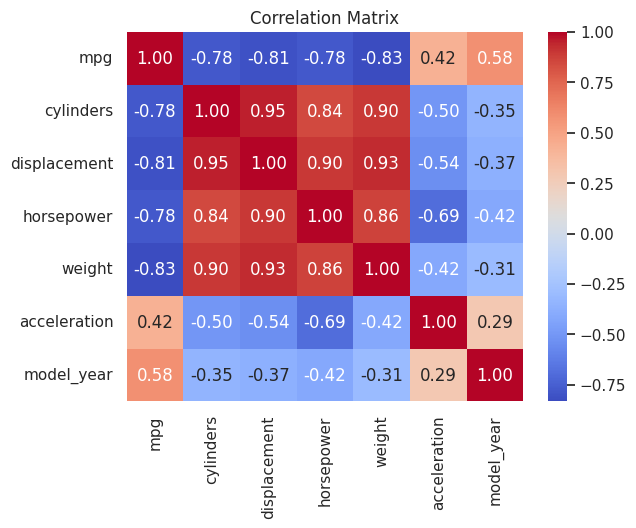

In [ ]:
corr = df_clean.select_dtypes(include="number").corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()


**2d.** Plot `weight` (x) vs. `mpg` (y) as a scatter plot. This will be our main predictor for the simple regression.


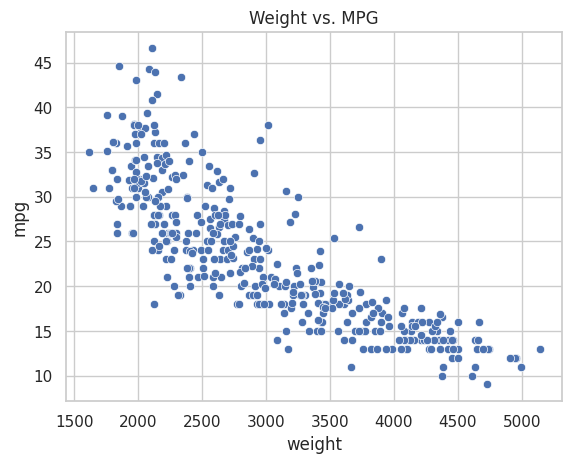

In [ ]:
sns.scatterplot(data=df_clean, x="weight", y="mpg")
plt.title("Weight vs. MPG")
plt.show()



## 3. Prepare features and target

**3a.** Create the feature matrix `X` with a single column `weight`, and the target vector `y` containing `mpg`.


In [ ]:
X = df_clean[["weight"]]
y = df_clean["mpg"]

print("X shape:", X.shape)
print("y shape:", y.shape)



X shape: (392, 1)
y shape: (392,)


## 4. Train / test split

Split the data into training (80 %) and test (20 %) sets. Use `random_state=42` for reproducibility.
[Docs
](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html)

In [ ]:
# YOUR CODE HERE
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42
)
print("Train:", X_train.shape, " Test:", X_test.shape)


Train: (313, 1)  Test: (79, 1)


## 5. Fit the [linear regression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html) model

Create a `LinearRegression` object, fit it on the **training** data.


In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

## 6. Make predictions

Use the fitted model to predict on the **test** set.


In [ ]:
y_pred = model.predict(X_test)
y_pred[:10]


array([29.89952329, 25.1099354 , 32.97402773, 31.74896812, 25.14945345,
       30.16824605,  9.68999154, 29.29884891, 21.40314213, 32.44448584])

## 7. Evaluate the model

**7a.** Compute MSE, MAE, and R² on the test set.


In [ ]:
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"MSE : {mse:.2f}")
print(f"MAE : {mae:.2f}")
print(f"R² : {r2:.4f}")



MSE : 17.69
MAE : 3.46
R² : 0.6533


**7b. Optional.** In your own words, is this R² value good or bad? What does it tell us?


In [ ]:
# R² = 0.6533 An R² of 0.6533 means that approximately 65.33% of the variation in car MPG can be explained by the car's
# weight according to your model. The remaining 34.67% of the variance is unexplained by this single feature model,
# indicating that other factors not included in the model contribute to the variability in MPG.



## 8. Visualise predictions

**8a.** Plot predicted vs. actual `mpg`. Add a diagonal reference line (perfect predictions would lie on it).


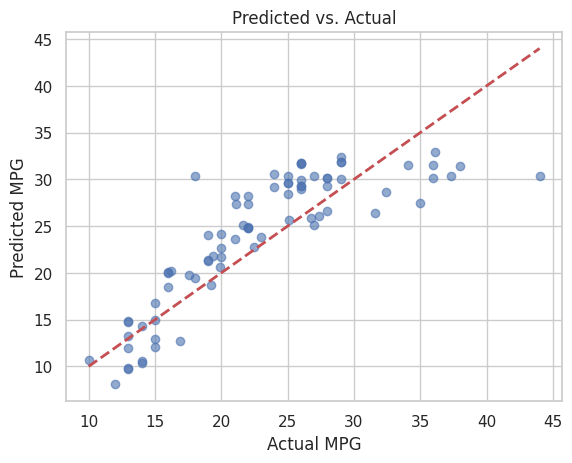

In [ ]:
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()],
[y_test.min(), y_test.max()], "r--", lw=2)
plt.xlabel("Actual MPG")
plt.ylabel("Predicted MPG")
plt.title("Predicted vs. Actual")
plt.show()


**8b.** Plot the original scatter (weight vs. mpg) with the fitted regression line overlaid.


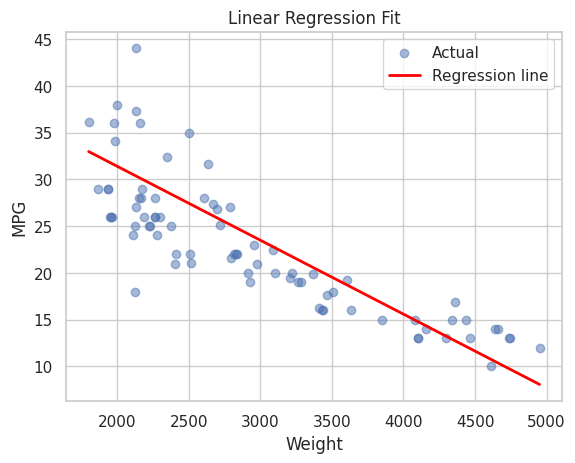

In [ ]:
plt.scatter(X_test, y_test, alpha=0.5, label="Actual")
plt.plot(X_test.sort_values("weight"),
model.predict(X_test.sort_values("weight")),
color="red", lw=2, label="Regression line")
plt.xlabel("Weight")
plt.ylabel("MPG")
plt.title("Linear Regression Fit")
plt.legend()
plt.show()



## 9. Inspect model coefficients

Print the model's coefficient (slope) and intercept. Interpret what the slope means in plain English.


In [ ]:
print(f"Coefficient (slope) : {model.coef_[0]:.6f}")
print(f"Intercept : {model.intercept_:.4f}")

# Alternative interpretation of the slope:
# For every 1000-pound increase in a car's weight, the predicted fuel efficiency (MPG) is estimated to decrease by approximately 7.9 MPG.
# The intercept of 47.2005 represents the predicted MPG when the car's weight is zero, a theoretical value that acts as the y-intercept of the regression line.

Coefficient (slope) : -0.007904
Intercept : 47.2005


---
**Well done!** You have built, evaluated, and visualised a linear regression model from scratch.
